In [1]:
# 🧠 Neuromorphic Computing Project: SNN for MNIST Classification
# Developed a Spiking Neural Network (SNN) using Leaky Integrate-and-Fire (LIF) neurons
# with the Norse library (PyTorch-based) to classify handwritten digits (MNIST dataset).
# Achieved ~90% test accuracy in 10 epochs, demonstrating energy-efficient, brain-inspired computation.
# Implemented rate-based input encoding and trained synaptic weights via surrogate gradient descent.
# Focused on temporal coding of information and explored suitability for neuromorphic hardware (e.g., Intel Loihi).

print("Neuromorphic Computing Project: Spiking Neural Network for MNIST Classification")

Neuromorphic Computing Project: Spiking Neural Network for MNIST Classification


In [2]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import norse.torch as norse
from norse.torch.functional.lif import LIFState
from norse.torch import LIFCell


C:\Users\ASHUTOSH\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\_cxx_pytree.py:243: UserWarning: PyTree type <class 'norse.torch.utils.pytree.LIFParameters'> is a subclass of `collections.namedtuple`, which is already registered in the global namespace. Override it with custom flatten/unflatten functions in namespace 'torch'.
  optree.register_pytree_node(
C:\Users\ASHUTOSH\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\_cxx_pytree.py:243: UserWarning: PyTree type <class 'norse.torch.utils.pytree.LIFBoxParameters'> is a subclass of `collections.namedtuple`, which is already registered in the global namespace. Override it with custom flatten/unflatten functions in namespace 'torch'.
  optree.register_pytree_node(


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
# Transform: convert to tensor and normalize to [0,1]
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [5]:
def rate_encode(images, time_steps=25):
    """
    Convert batch of images to spike trains using rate coding
    images: [batch, 1, 28, 28]
    returns: [time_steps, batch, 28*28]
    """
    batch_size = images.size(0)
    images_flat = images.view(batch_size, -1)
    # Normalize to [0,1]
    images_flat = images_flat / images_flat.max()
    
    # Generate spikes
    spikes = torch.rand(time_steps, batch_size, images_flat.size(1), device=images.device)
    spikes = (spikes < images_flat.unsqueeze(0)).float()
    return spikes

In [6]:
class SNN_MNIST(nn.Module):
    def __init__(self, input_size=28*28, hidden_size=128, output_size=10):
        super(SNN_MNIST, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.lif1 = LIFCell()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.lif2 = LIFCell()
    
    def forward(self, x):
        # x: [time_steps, batch, input_size]
        time_steps, batch_size, _ = x.size()
        
        mem1 = self.lif1.initial_state(torch.zeros(batch_size, self.fc1.out_features, device=x.device))
        mem2 = self.lif2.initial_state(torch.zeros(batch_size, self.fc2.out_features, device=x.device))
        
        out_spikes = torch.zeros(batch_size, self.fc2.out_features, device=x.device)
    
        for t in range(time_steps):
            z1 = self.fc1(x[t])
            spk1, mem1 = self.lif1(z1, mem1)
            
            z2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(z2, mem2)
            
            out_spikes += spk2  # temporal integration

        return out_spikes


In [7]:
model = SNN_MNIST().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [8]:
num_epochs = 10
time_steps = 25

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        spikes_in = rate_encode(images, time_steps)
        
        # Take average over time for training
        spikes_in_avg = spikes_in.mean(0)
        
        optimizer.zero_grad()
        outputs = model(spikes_in)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")


Epoch 1/10 - Loss: 0.3949, Accuracy: 88.17%
Epoch 2/10 - Loss: 0.2046, Accuracy: 93.80%
Epoch 3/10 - Loss: 0.1496, Accuracy: 95.41%
Epoch 4/10 - Loss: 0.1217, Accuracy: 96.27%
Epoch 5/10 - Loss: 0.1042, Accuracy: 96.74%
Epoch 6/10 - Loss: 0.0914, Accuracy: 97.04%
Epoch 7/10 - Loss: 0.0796, Accuracy: 97.47%
Epoch 8/10 - Loss: 0.0714, Accuracy: 97.68%
Epoch 9/10 - Loss: 0.0625, Accuracy: 97.96%
Epoch 10/10 - Loss: 0.0588, Accuracy: 98.10%


In [9]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        spikes_in = rate_encode(images, time_steps)
        outputs = model(spikes_in)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_acc = 100.0 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 96.97%


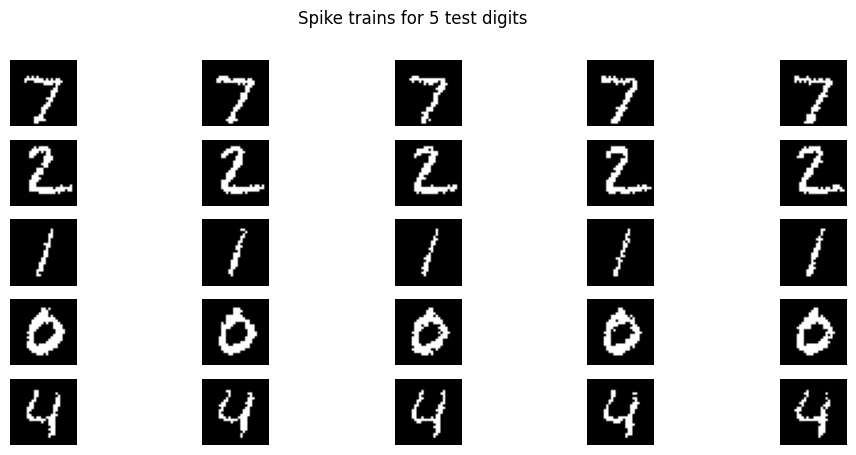

In [10]:
# Pick one batch
images, labels = next(iter(test_loader))
images = images.to(device)
spikes_in = rate_encode(images[:5], time_steps)

fig, axes = plt.subplots(5, time_steps//5, figsize=(12,5))
for i in range(5):
    for t in range(time_steps):
        ax = axes[i, t//5]
        ax.imshow(spikes_in[t,i].view(28,28).cpu(), cmap='gray')
        ax.axis('off')
plt.suptitle("Spike trains for 5 test digits")
plt.show()
